##**SHETH L.U.J. & SIR M.V. COLLEGE**

####Vedant Patil | T101

Regression and Its Types

*   Implement simple linear regression using a dataset.
*   Explore and interpret the regression model coefficients and goodness-of-fit
measures.

*  Extend the analysis to multiple linear regression and assess the impact of
additional predictors.






### **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

### **Get dataset**

In [2]:
# Get dataset
df = pd.read_csv('pokemon.csv')
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


### **Describe data**

In [3]:
# Describe data
df.describe()

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,height_m,hp,percentage_male,pokedex_number,sp_attack,sp_defense,speed,weight_kg,generation,is_legendary
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,...,781.000000,801.000000,703.000000,801.000000,801.000000,801.000000,801.000000,781.000000,801.000000,801.000000
mean,0.996255,1.057116,0.968789,1.073970,1.068976,1.065543,1.135456,1.192884,0.985019,1.034020,...,1.163892,68.958801,55.155761,401.000000,71.305868,70.911361,66.334582,61.378105,3.690387,0.087391
std,0.597248,0.438142,0.353058,0.654962,0.522167,0.717251,0.691853,0.604488,0.558256,0.788896,...,1.080326,26.576015,20.261623,231.373075,32.353826,27.942501,28.907662,109.354766,1.930420,0.282583
min,0.250000,0.250000,0.000000,0.000000,0.250000,0.000000,0.250000,0.250000,0.000000,0.250000,...,0.100000,1.000000,0.000000,1.000000,10.000000,20.000000,5.000000,0.100000,1.000000,0.000000
25%,0.500000,1.000000,1.000000,0.500000,1.000000,0.500000,0.500000,1.000000,1.000000,0.500000,...,0.600000,50.000000,50.000000,201.000000,45.000000,50.000000,45.000000,9.000000,2.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,65.000000,50.000000,401.000000,65.000000,66.000000,65.000000,27.300000,4.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.500000,80.000000,50.000000,601.000000,91.000000,90.000000,85.000000,64.800000,5.000000,0.000000
max,4.000000,4.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,14.500000,255.000000,100.000000,801.000000,194.000000,230.000000,180.000000,999.900000,7.000000,1.000000


### **Data distribution**

We will look at the distribution of the target variable, **attack**.

/tmp/ipython-input-3603306682.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['attack'])


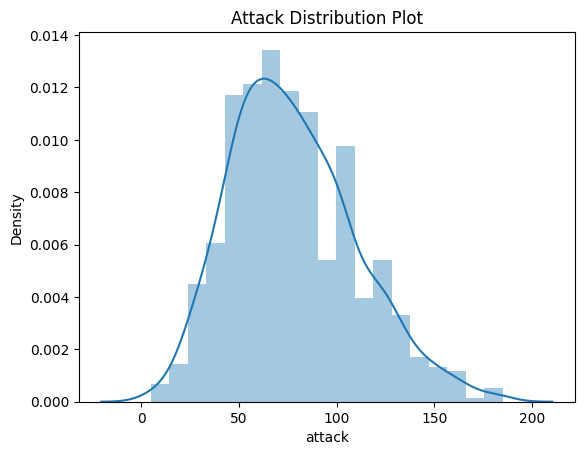

In [4]:
# Data distribution
plt.title('Attack Distribution Plot')
sns.distplot(df['attack'])
plt.show()

### **Relationship between Attack and Defense**

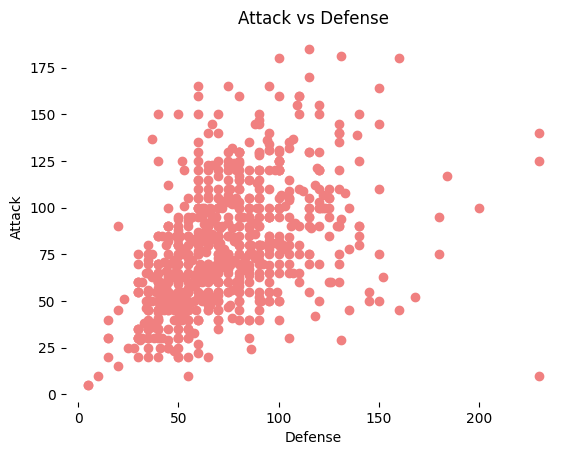

In [5]:
# Relationship between Attack and Defense
plt.scatter(df['defense'], df['attack'], color = 'lightcoral')
plt.title('Attack vs Defense')
plt.xlabel('Defense')
plt.ylabel('Attack')
plt.box(False)
plt.show()

### **Split dataset in dependent/independent variables**

We select **type1**, **hp**, **defense**, **speed**, and **is\_legendary** as our independent variables (X) to predict **attack** (y).

In [6]:
# Select relevant columns for the model
# Features: type1, hp, defense, speed, is_legendary
# Target: attack
dataset = df[['type1', 'hp', 'defense', 'speed', 'is_legendary', 'attack']]

# Split dataset in dependent/independent variables
X = dataset.iloc[:, :-1].values  # All columns except the last one
y = dataset.iloc[:, -1].values   # The last column (attack)

### **One-hot encoding of categorical data**

We need to encode the **type1** column, which is at index 0 in our new X variable.

In [11]:
# One-hot encoding of categorical data
# Encoding 'type1' (index 0)

# Re-initialize X to ensure correct input format for ColumnTransformer
# This step ensures X is properly reset from the original DataFrame.
dataset = df[['type1', 'hp', 'defense', 'speed', 'is_legendary', 'attack']]
X = dataset.iloc[:, :-1].values

# Debugging prints to verify X's state before ColumnTransformer
print(f"Shape of X before ColumnTransformer: {X.shape}")
print(f"Type of X before ColumnTransformer: {type(X)}")
print(f"Number of dimensions of X before ColumnTransformer: {len(X.shape)}")

ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [0])], remainder = 'passthrough')
X = ct.fit_transform(X).toarray()

Shape of X before ColumnTransformer: (801, 5)
Type of X before ColumnTransformer: <class 'numpy.ndarray'>
Number of dimensions of X before ColumnTransformer: 2


### **Split dataset into test/train**

In [12]:
# Split dataset into test/train
# Ensure X is a dense array, handling cases where it might be a scalar array of a sparse matrix
if isinstance(X, np.ndarray) and X.dtype == object and X.shape == () and hasattr(X.item(), 'toarray'):
    X = X.item().toarray()
elif hasattr(X, 'toarray'):
    X = X.toarray()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### **Train multiple regression model**

In [13]:
# Train multiple regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

### **Predict result**

In [14]:
# Predict result
y_pred = regressor.predict(X_test)

### **Compare predicted result with actual value**

In [15]:
# Compare predicted result with actual value
np.set_printoptions(precision = 2)
result = np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1)
print(result)

[[ 98.1  103.  ]
 [103.88 110.  ]
 [ 59.51  45.  ]
 [ 79.04  70.  ]
 [ 87.8  150.  ]
 [ 50.7    5.  ]
 [ 82.86  80.  ]
 [ 71.8  100.  ]
 [112.31 160.  ]
 [ 84.1  100.  ]
 [109.12  75.  ]
 [ 84.8   50.  ]
 [ 40.63  65.  ]
 [ 80.54 100.  ]
 [ 61.21  40.  ]
 [111.79 100.  ]
 [ 72.26  41.  ]
 [ 94.9  100.  ]
 [ 36.97  72.  ]
 [ 82.5   60.  ]
 [ 94.9  100.  ]
 [ 77.86 130.  ]
 [ 76.26  78.  ]
 [112.    10.  ]
 [ 88.64  60.  ]
 [ 57.7   50.  ]
 [ 78.84 120.  ]
 [ 87.76  80.  ]
 [ 93.87 125.  ]
 [ 82.99  97.  ]
 [101.81  50.  ]
 [ 82.33  80.  ]
 [ 99.54 120.  ]
 [ 65.27  75.  ]
 [ 89.63  80.  ]
 [ 52.9   30.  ]
 [ 49.64  57.  ]
 [ 80.43  50.  ]
 [ 63.57  70.  ]
 [ 74.2   65.  ]
 [113.62 181.  ]
 [ 85.92  60.  ]
 [ 82.98  87.  ]
 [ 47.5   45.  ]
 [ 93.23 115.  ]
 [ 98.19  85.  ]
 [ 76.35 110.  ]
 [ 71.59  85.  ]
 [ 51.57  60.  ]
 [ 69.3   92.  ]
 [ 78.36  60.  ]
 [102.37  95.  ]
 [ 64.07  50.  ]
 [ 69.56  85.  ]
 [ 69.24  35.  ]
 [ 62.97  50.  ]
 [ 92.76  70.  ]
 [116.31 115.  ]
 [102.49 105. 